# **Predicting Park Access Rankings Across U.S. Cities**
**Authors**: Jingyuan Liu, Shivani Aggarwal, Sarenna Ulman, Luna Gulec

## Summary

## Introduction

#### Background Information

#### Research Question

#### About the Dataset

The dataset we used to answer the question is a dataset collected by the Trust for Public Land.  They have a mission to ensure that every American has access to a good quality park within a 10-minute walking distance. To support this, they collect data every year, and the data we are using was collected in 2021.  

The dataset contains annual park system data for major U.S. cities up to 2021 and is sourced from the Trust for Public Land’s ParkScore index. The data was obtained from the TidyTuesday repository and can be accessed [here](https://github.com/rfordatascience/tidytuesday/blob/main/data/2021/2021-06-22/readme.md).

The main goal of collecting the data was to assess if the residents of major US cities had sufficient access to parks, and to measure and rank the quality of each city's parks. The dataset is publicly hosted on GitHub, ensuring maximum reproducibility. You can read more about Trust for Public Land's initiative [here](https://www.tpl.org/parks-and-an-equitable-recovery-parkscore-report). 

#### Data Dictionary
**Note that "points" are essentially their yearly normalized values (higher points = better).**

|variable                  |class     |description |
|:-------------------------|:---------|:-----------|
|year                      |double    | Year of measurement |
|rank                      |double    | Yearly rank |
|city                      |character | City Name |
|med_park_size_data        |double    | Median park size acres |
|med_park_size_points      |double    | Median park size in points |
|park_pct_city_data        |character | Parkland as percentage of city area |
|park_pct_city_points      |double    | Parkland as % of city area points |
|pct_near_park_data        |character | Percent of residents within a 10 minute walk to park |
|pct_near_park_points      |double    | Percent of residents within a 10 minute walk to park points |
|spend_per_resident_data   |character | Spending per resident in USD |
|spend_per_resident_points |double    | Spending per resident in points |
|basketball_data           |double    | Basketball hoops per 10,000 residents |
|basketball_points         |double    | Basketball hoops per 10,000 residents points |
|dogpark_data              |double    | Dog parks per 100,000 residents|
|dogpark_points            |double    | Dog parks per 100,000 residents points |
|playground_data           |double    | Playgrounds per 10,000 residents |
|playground_points         |double    | Playgrounds per 10,000 residents points |
|rec_sr_data               |double    | Recreation and senior centers per 20,000 residents |
|rec_sr_points             |double    | Recreation and senior centers per 20,000 residents points |
|restroom_data             |double    | Restrooms per 10,000 residents |
|restroom_points           |double    | Restrooms per 10,000 residents points |
|splashground_data         |double    | Splashgrounds and splashpads per 100,000 residents |
|splashground_points       |double    | Splashgrounds and splashpads per 100,000 residents points |
|amenities_points          |double    | Amenities points total (ie play areas) |
|total_points              |double    | Total points (varies in denominator per/year) |
|total_pct                 |double    | Total points as a percentage|
|city_dup                  |character | City duplicated name |
|park_benches              |double    | Number of park benches|
This can also be found at the data website [here](https://github.com/rfordatascience/tidytuesday/blob/main/data/2021/2021-06-22/readme.md).

## Methods & Results

First, we need to import all necessary packages for this analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import statistics
from IPython.display import display, HTML
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import loguniform

from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#### Data Wrangling and Cleaning

We then load data from the original source on the web. Here, we present the first 5 rows of the raw data.

In [2]:
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2021/2021-06-22/parks.csv"
data_raw = pd.read_csv(url)
data_raw.head()

,year,rank,city,med_park_size_data,med_park_size_points,park_pct_city_data,park_pct_city_points,pct_near_park_data,pct_near_park_points,spend_per_resident_data,...,rec_sr_points,restroom_data,restroom_points,splashground_data,splashground_points,amenities_points,total_points,total_pct,city_dup,park_benches
0,2020,1,Minneapolis,5.7,26.0,15%,38.0,98%,98.0,$319,...,100.0,2.9,91.0,4.0,100.0,79.3,341.0,85.3,Minneapolis,NaN
1,2020,2,"Washington, D.C.",1.4,5.0,24%,50.0,98%,98.0,$307,...,100.0,2.6,80.0,4.1,100.0,80.3,333.0,83.3,"Washington, D.C.",NaN
2,2020,3,St. Paul,3.2,14.0,15%,39.0,99%,99.0,$219,...,100.0,3.2,100.0,1.3,47.0,78.0,330.0,82.5,St. Paul,NaN
3,2020,4,"Arlington, Virginia",2.4,10.0,11%,28.0,99%,99.0,$301,...,76.0,3.1,97.0,2.2,81.0,89.0,326.0,81.5,"Arlington, Virginia",NaN
4,2020,5,Cincinnati,4.4,20.0,14%,36.0,82%,74.0,$190,...,100.0,3.2,98.0,4.5,100.0,92.5,323.0,80.6,Cincinnati,NaN


In [3]:
data_raw.shape

(713, 28)

We can see that the original raw dataset has 713 rows and 28 columns. Then, we will perform data wrangling to clean the data from it’s original format to the format necessary for the purpose of this analysis.

Since this dataset records the yearly rankings of park access across U.S. cities, it is inherently time-series data. However, advanced time-series methods are beyond the scope of this course. Instead, we will extract each city's rank from the last time, denoted as `rank_last_time`, to capture basic year-to-year trends. For the first observation year of a city, we decide to impute its `rank_last_time` with its ranking in the current year (i.e., `rank`).

In [4]:
data_processed = data_raw.sort_values(["city", "year"])
data_processed["rank_last_time"] = data_processed.groupby("city")["rank"].shift(1)
data_processed['rank_last_time'] = data_processed['rank_last_time'].fillna(data_processed['rank'])

We will then remove data from year 2012, 2013, and 2014 because there are so many missing values in those rows, which will not help with building a predictive model.

In [5]:
data_processed = data_processed[~data_processed["year"].isin([2012,2013,2014])]

We noticed that more than 10% of the data in columns `restroom_data`, `restroom_points`, `splashground_data`, `splashground_points`, `total_points`, `total_pct`, `city_dup`, and `park_benches` are missing, with some columns approaching 50%. Therefore, we decided to drop these columns as advanced data imputation methods are also beyond the scope of this course.

In [6]:
data_processed.isna().sum()
data_processed = data_processed.drop(columns=['restroom_data','restroom_points','splashground_data',
                                              'splashground_points','total_points','total_pct',
                                              'city_dup','park_benches'])

There are a total of more than 100 cities in this dataset, but each city only has fewer than 10 observations. This makes `city` not an ideal categorical variable for regression due to the potential overfitting issue. Therefore, we perform feature aggregation and add a new column called `state` so that each category has more valid observations. We will manually map each city into a state.

In [7]:
data_processed['city'].nunique()

101

In [8]:
city_to_state = {
    'Albuquerque': 'NM', 'Anaheim': 'CA', 'Anchorage': 'AK', 
    'Arlington, Texas': 'TX', 'Arlington, Virginia': 'VA', 'Atlanta': 'GA', 
    'Aurora': 'CO', 'Austin': 'TX', 'Bakersfield': 'CA', 'Baltimore': 'MD', 
    'Baton Rouge': 'LA', 'Boise': 'ID', 'Boston': 'MA', 'Buffalo': 'NY', 
    'Chandler': 'AZ', 'Charlotte': 'NC', 'Charlotte/Mecklenburg County': 'NC',
    'Chesapeake': 'VA', 'Chicago': 'IL', 'Chula Vista': 'CA', 'Cincinnati': 'OH', 
    'Cleveland': 'OH', 'Colorado Springs': 'CO', 'Columbus': 'OH', 
    'Corpus Christi': 'TX', 'Dallas': 'TX', 'Denver': 'CO', 'Des Moines': 'IA', 
    'Detroit': 'MI', 'Durham': 'NC', 'El Paso': 'TX', 'Fort Wayne': 'IN', 
    'Fort Worth': 'TX', 'Fremont': 'CA', 'Fresno': 'CA', 'Garland': 'TX', 
    'Glendale': 'AZ', 'Greensboro': 'NC', 'Henderson': 'NV', 'Hialeah': 'FL', 
    'Honolulu': 'HI', 'Houston': 'TX', 'Indianapolis': 'IN', 'Irvine': 'CA', 
    'Irving': 'TX', 'Jacksonville': 'FL', 'Jersey City': 'NJ', 'Kansas City': 'MO', 
    'Laredo': 'TX', 'Las Vegas': 'NV', 'Lexington': 'KY', 'Lincoln': 'NE', 
    'Long Beach': 'CA', 'Los Angeles': 'CA', 'Louisville': 'KY', 'Lubbock': 'TX', 
    'Madison': 'WI', 'Memphis': 'TN', 'Mesa': 'AZ', 'Miami': 'FL', 
    'Milwaukee': 'WI', 'Minneapolis': 'MN', 'Nashville': 'TN', 'New Orleans': 'LA', 
    'New York': 'NY', 'Newark': 'NJ', 'Norfolk': 'VA', 'North Las Vegas': 'NV', 
    'Oakland': 'CA', 'Oklahoma City': 'OK', 'Omaha': 'NE', 'Orlando': 'FL', 
    'Philadelphia': 'PA', 'Phoenix': 'AZ', 'Pittsburgh': 'PA', 'Plano': 'TX', 
    'Portland': 'OR', 'Raleigh': 'NC', 'Reno': 'NV', 'Richmond': 'VA', 
    'Riverside': 'CA', 'Sacramento': 'CA', 'San Antonio': 'TX', 'San Diego': 'CA', 
    'San Francisco': 'CA', 'San Jose': 'CA', 'Santa Ana': 'CA', 'Scottsdale': 'AZ', 
    'Seattle': 'WA', 'St. Louis': 'MO', 'St. Paul': 'MN', 'St. Petersburg': 'FL', 
    'Stockton': 'CA', 'Tampa': 'FL', 'Toledo': 'OH', 'Tucson': 'AZ', 'Tulsa': 'OK', 
    'Virginia Beach': 'VA', 'Washington, D.C.': 'DC', 'Wichita': 'KS', 
    'Winston-Salem': 'NC'
}
data_processed['state'] = data_processed['city'].map(city_to_state)

Finally, we will convert columns `year`, `city`, and `state` to type `category`, and columns `rank` and `rank_last_time` to type `int`. In addition, we know that variables ending with "points" are essentially their yearly normalized values (higher points = better), so we decided to remove raw numerical variables (i.e., variables ending with `"_data"`) and just keep the normalized ones with potential categorical variables in the model. In particular, our response variable is **`rank`**!

In [9]:
data_processed['year'] = data_processed['year'].astype('category')
data_processed['city'] = data_processed['city'].astype('category')
data_processed['state'] = data_processed['state'].astype('category')
data_processed['rank'] = data_processed['rank'].astype('int')
data_processed['rank_last_time'] = data_processed['rank_last_time'].astype('int')
data_processed = data_processed.drop(columns=data_processed.filter(regex='data$').columns)

Finally, we can review the processed dataset and export it as a CSV to the `/data/processed` directory, and now we are ready to proceed!

In [10]:
data_processed.head(10)

,year,rank,city,med_park_size_points,park_pct_city_points,pct_near_park_points,spend_per_resident_points,basketball_points,dogpark_points,playground_points,rec_sr_points,amenities_points,rank_last_time,state
500,2015,13,Albuquerque,8.0,20.0,32.0,7.0,8.0,20.0,10.0,15.0,53.0,15,NM
409,2016,20,Albuquerque,8.0,20.0,31.0,6.0,8.0,20.0,11.0,14.0,13.0,13,NM
307,2017,17,Albuquerque,8.0,20.0,31.0,6.0,7.0,20.0,11.0,13.0,13.0,20,NM
233,2018,40,Albuquerque,8.0,20.0,30.0,10.0,11.0,40.0,24.0,27.0,21.0,17,NM
130,2019,34,Albuquerque,20.0,50.0,82.5,27.5,25.0,100.0,57.5,68.0,52.1,40,NM
34,2020,35,Albuquerque,19.0,50.0,81.0,30.0,27.0,100.0,52.0,91.0,60.8,34,NM
538,2015,51,Anaheim,17.0,7.0,22.0,6.0,4.0,3.0,3.0,2.0,12.0,36,CA
454,2016,65,Anaheim,17.0,8.0,19.0,7.0,4.0,2.0,4.0,2.0,3.0,51,CA
353,2017,63,Anaheim,17.0,8.0,19.0,7.0,3.0,4.0,4.0,2.0,3.0,65,CA
261,2018,68,Anaheim,16.0,8.0,19.0,13.0,4.0,7.0,7.0,5.0,11.0,63,CA


In [11]:
data_processed.to_csv("../data/processed/parks_processed.csv", index=False)

#### Exploratory Data Analysis & Visualization

First, we have to split the data into a training set and test set, so we don't touch the test set during the exploratory data analysis.

In [12]:
X = data_processed.drop(['rank'], axis = 1)
y = data_processed['rank']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8) 

Next, we will look at the distribution of ranks in the training set.  

Minimum rank: 1
Maximum rank: 98
Average rank: 47.727
Median rank: 47.0
Most common rank: 24


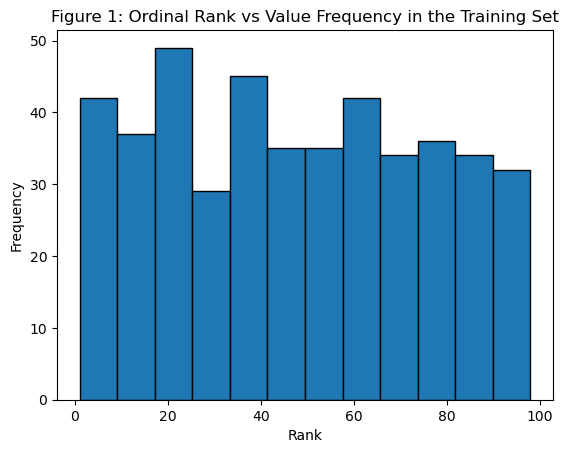

In [13]:
print(f"Minimum rank: {y_train.min()}")
print(f"Maximum rank: {y_train.max()}")
print(f"Average rank: {round(y_train.mean(), 3)}")
print(f"Median rank: {y_train.median()}")
print(f"Most common rank: {statistics.mode(y_train)}")

plt.hist(y_train, bins = 12, edgecolor='black')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Figure 1: Ordinal Rank vs Value Frequency in the Training Set");

The ranks are somewhat evenly distributed, with a slight majority of parks receiving a lower rank.  

In [14]:
print("Number of rows in the training X dataset:", len(X_train))
display(HTML("<h3>Table 1:  Summary of the Training Dataset</h3>"))
X_train.describe()

Number of rows in the training X dataset: 450


,med_park_size_points,park_pct_city_points,pct_near_park_points,spend_per_resident_points,basketball_points,dogpark_points,playground_points,rec_sr_points,amenities_points,rank_last_time
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,15.814444,15.098889,34.324444,25.491111,23.143333,23.197778,22.490000,25.771111,28.076667,45.291111
std,12.443928,11.833416,23.565297,25.850433,24.019805,26.054483,21.884909,25.445755,20.168912,26.960041
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,2.000000,1.000000
25%,7.000000,7.000000,17.000000,8.000000,7.000000,6.000000,8.000000,8.000000,11.000000,22.000000
50%,13.000000,12.250000,29.000000,16.500000,14.000000,14.000000,14.000000,17.000000,21.000000,43.000000
75%,20.000000,20.000000,40.000000,33.750000,30.000000,27.875000,30.000000,38.000000,43.950000,66.750000
max,50.000000,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,92.500000,98.000000


The first thing to note is that every column has 450 values, meaning all of the NA values were successfully removed.  Most of the point scales are out of 100, and the average number of points hovers between 15-30 points in all categories.  

Since we expect previous ranks to be quite important in predicting the current rank, we will look at the distribution of the feature `rank_last_time`.

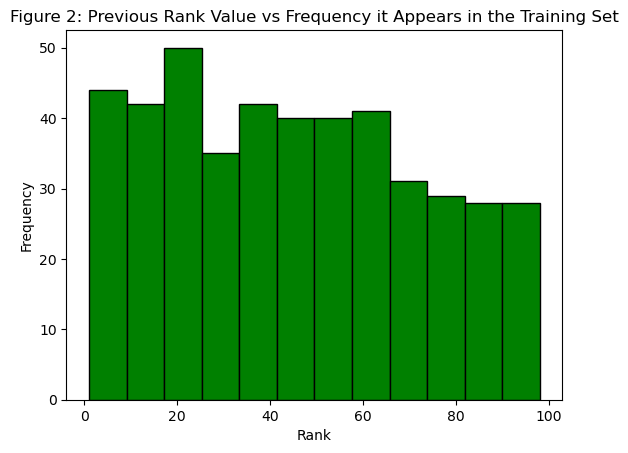

In [15]:
plt.hist(X_train['rank_last_time'], bins = 12, edgecolor='black', color = 'green')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Figure 2: Previous Rank Value vs Frequency it Appears in the Training Set");

We see a similar distribution as the target variable, with a decent majority of the ranks being on the lower half of the spectrum.

Lastly, we will inspect the distributions of the point-based features in a more visually interpretable boxplot.  We will also be able to check for outliers this way.

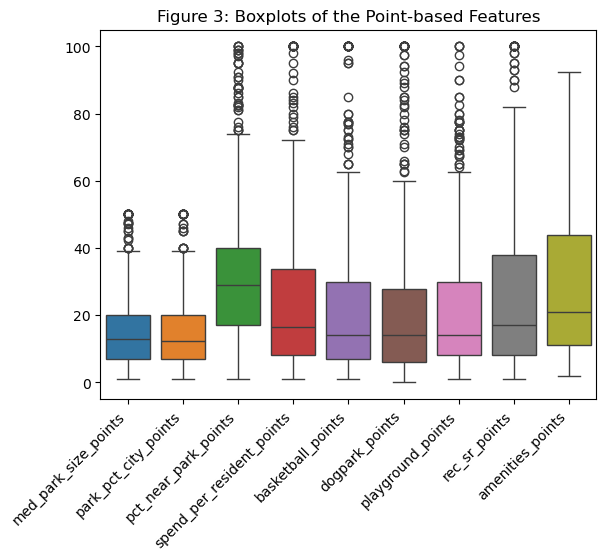

In [16]:
columns_to_plot = ['med_park_size_points', 'park_pct_city_points',
       'pct_near_park_points', 'spend_per_resident_points',
       'basketball_points', 'dogpark_points', 'playground_points',
       'rec_sr_points', 'amenities_points']

sns.boxplot(data=X_train[columns_to_plot])
plt.title("Figure 3: Boxplots of the Point-based Features")
plt.xticks(rotation=45, ha='right')
plt.show()

The medians are relatively similar, except for `pct_near_park_points`, and most columns have similar standard deviations.  Something to note is every feature, with the exception for `amenities_points`, has several outliers.  Additionally, the features `med_park_size_points` and `park_pct_city_points` have nearly identical distributions.  

#### Regression Analysis 

Since our target variable `rank` is a discrete numerical variable ranging from 1 to 98, it would be best to use **ridge regression** to build a predictive model. We will process the categorical variable `state` using one hot encoding to convert it into numerical data. We will drop `city` as a feature as it perfectly correlates with `state`. We will also scale all numerical features to a standardized scale. 

In [17]:
# isolating different types of features
categorical_features = X_train.select_dtypes(include=['category']).drop(columns=['city']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['int', 'float']).columns.tolist()
drop_features = ['city']

# preprocessor
preprocessor = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_features),
    (StandardScaler(), numerical_features),
    ("drop", drop_features)
)

# model pipeline
pipe = make_pipeline(preprocessor, Ridge())

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

Before implementing the model on the data, we will optimize the regularization hyperparameter $alpha$ through randomized grid search. This will test the model performance using different values of $alpha$ and pick the one that results in the best performance.

In [18]:
# hyperparameter tuning
param_grid = {'ridge__alpha': loguniform(1e-3, 1e3)}

grid_search = RandomizedSearchCV(pipe, param_distributions=param_grid, n_iter=100, n_jobs=-1, return_train_score=True)
grid_search.fit(X_train, y_train)

# results
print(f"Best alpha: {grid_search.best_params_['ridge__alpha']:.4f}")
print(f"Best performance: {grid_search.best_score_:.4f}")

Best alpha: 6.9584
Best performance: 0.9479


This model can predict `rank` with an almost perfect accuracy of $94.8%$. This seems a bit unrealistic so let's take a look at the coefficients to see if there are any unexpected relationships.

In [19]:
# get feature names after preprocessing
feature_names = grid_search.best_estimator_.named_steps['columntransformer'].get_feature_names_out()

# zip into a dataframe
train_coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': grid_search.best_estimator_.named_steps['ridge'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

train_coef_df['feature'] = train_coef_df['feature'].str.replace('onehotencoder__', '').str.replace('standardscaler__', '')

train_coef_df.head(10)

,feature,coefficient
50,rank_last_time,24.188973
2,year_2017,-5.283272
3,year_2018,-3.596778
0,year_2015,3.151369
49,amenities_points,-2.651544
23,state_MI,2.618446
4,year_2019,2.544522
17,state_IN,2.387344
5,year_2020,2.062662
15,state_ID,-1.826254


We can see that `rank_last_time` is skewing the results. This is expected as it technically serves as a proxy to `rank`. Since park quality within a city is unlikely to change dramatically from year to year, including the previous year’s ranking introduced data leakage and led the model to rely too heavily on past rankings rather than learning relationships between park characteristics and ParkScore rank. 

Therefore, we will build another model without `rank_last_time` to evaluate its effectiveness. After dropping `rank_last_time`, we would be left with perfectly standardized numerical features, and therefore, they would not require any scaling anymore.

In [20]:
# removing rank_last_time
numerical_features.remove('rank_last_time')
drop_features.append('rank_last_time')

# preprocessor
preprocessor_new = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ("passthrough", numerical_features),
    ("drop", drop_features)
)

# model pipeline
pipe_new = make_pipeline(preprocessor, Ridge())

pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...), ('standardscaler', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [21]:
# hyperparameter tuning
grid_search_new = RandomizedSearchCV(pipe_new, param_distributions=param_grid, n_iter=100, n_jobs=-1, return_train_score=True)
grid_search_new.fit(X_train, y_train)

# results
print(f"Best alpha: {grid_search_new.best_params_['ridge__alpha']:.4f}")
print(f"Best performance: {grid_search_new.best_score_:.4f}")

Best alpha: 0.5018
Best performance: 0.7643


This looks like a much realistic result. Now we will fit the model on the training data using $alpha = 0.5343$ and evaluate its performance on the test set.

In [22]:
# predictions
final_pipe = make_pipeline(preprocessor, Ridge(alpha=grid_search_new.best_params_['ridge__alpha']))
final_pipe.fit(X_train, y_train)

round(final_pipe.score(X_test, y_test), 4)

0.7685

#### Results & Visualizations

The model performed exceptionally well on the testing data. Let's look at the coefficients and understand the relationships between the predictor variables and the target.

In [23]:
# get feature names after preprocessing
feature_names = final_pipe.named_steps['columntransformer'].get_feature_names_out()

# zip into a dataframe
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': final_pipe.named_steps['ridge'].coef_
}).sort_values('coefficient', key=abs, ascending=False)

coef_df['feature'] = coef_df['feature'].str.replace('onehotencoder__', '').str.replace('standardscaler__', '')

In [24]:
# top 10 features
coef_df.head(10)

,feature,coefficient
5,year_2020,45.524037
4,year_2019,44.075956
17,state_IN,28.551167
2,year_2017,-25.164848
1,year_2016,-24.850024
0,year_2015,-21.817031
3,year_2018,-17.768091
10,state_DC,-16.693176
39,state_WA,-13.618144
40,state_WI,-13.568382


In [25]:
# bottom 5 features
coef_df.tail(5)

,feature,coefficient
30,state_NV,0.702791
13,state_HI,-0.490515
48,rec_sr_points,0.242196
46,dogpark_points,0.197651
45,basketball_points,-0.031637


**Results** \
Since a lower rank is better, a positive coefficient predicts a worse rank whereas as a negative coefficient predicts a better rank. 
- We can see that cities in 2020 and 2019 tend to receive much worse predicted ranks compared to the baseline year, 2021, whereas from 2015-2018, cities tend to rank better. These shifts in ranking across years possibly reflects changes in the ranking methodology or shifts in overall park system scores across years rather than true differences in park quality.
- Cities in Indiana tend to rank worse versus cities in Washington DC, Wisconsin, and Washington tend to rank better than the baseline.

Since the largest coefficients correspond primarily to year and state indicators, we can say that temporal and geographic variation plays a significant role in predicting `rank`. 

Text(0.5, 1.0, 'Actual vs Predicted Ranks')

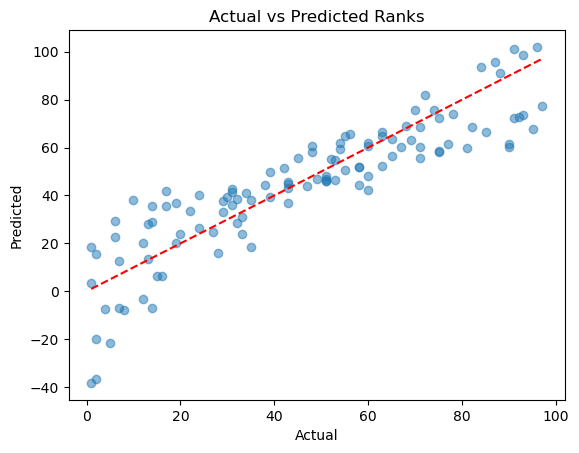

In [26]:
# actual vs predicted ranks
y_pred = final_pipe.predict(X_test)

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Ranks')

## Discussion

## References

Chapman, Ronda, et al. “Parks and an Equitable Recovery.” *The Trust for Public Land*, 27 May 2021,\
&emsp;&emsp;www.tpl.org/parks-and-an-equitable-recovery-parkscore-report. Accessed 4 Mar. 2026.
<br><br>
Data Science Learning Community. "Tidy Tuesday: A weekly social data project". *GitHub*, 2024. https://tidytues.day.
<br><br>
jonthegeek. “Park Access.” *GitHub*, Data Science Learning Community, 22 June 2021,\
&emsp;&emsp;github.com/rfordatascience/tidytuesday/blob/main/data/2021/2021-06-22/readme.md. Accessed 4 Mar. 2026.
<br><br>
Poon, Linda, and Marie Patino. “The Inequality of American Parks.” *Bloomberg*, 27 May 2021,\
&emsp;&emsp;www.bloomberg.com/news/articles/2021-05-27/the-cities-where-people-of-color-can-walk-to-a-park. \
&emsp;&emsp;Accessed 4 Mar. 2026.

